<a href="https://colab.research.google.com/github/Raviteja0707200/Retail-Demand-Forecasting-and-Inventory-Analysis-project/blob/main/Retail_Demand_Forecasting_and_Inventory_Analysis_project%2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 

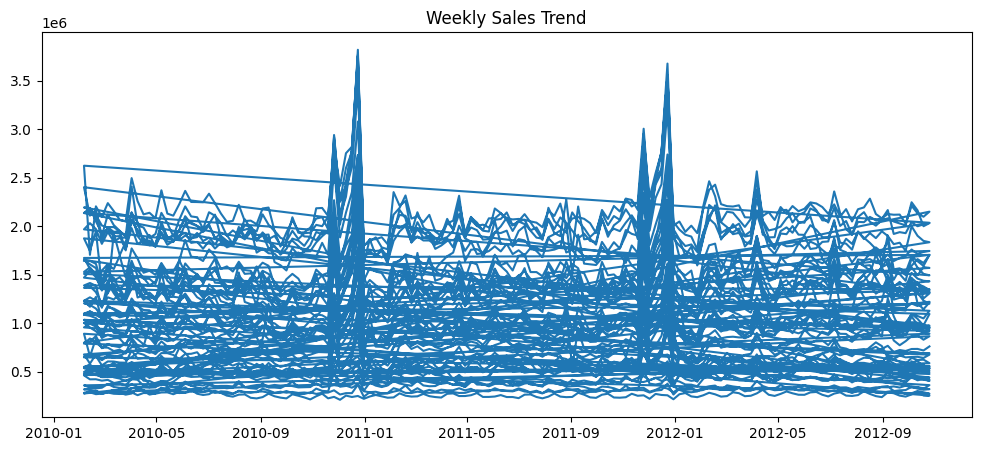

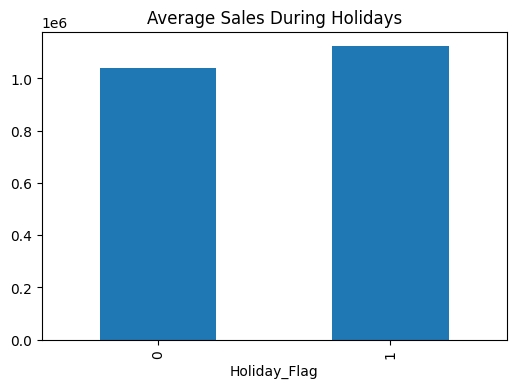

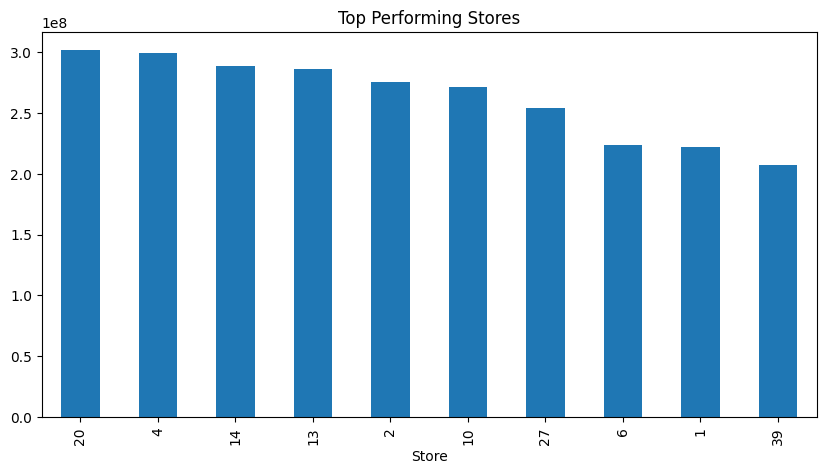

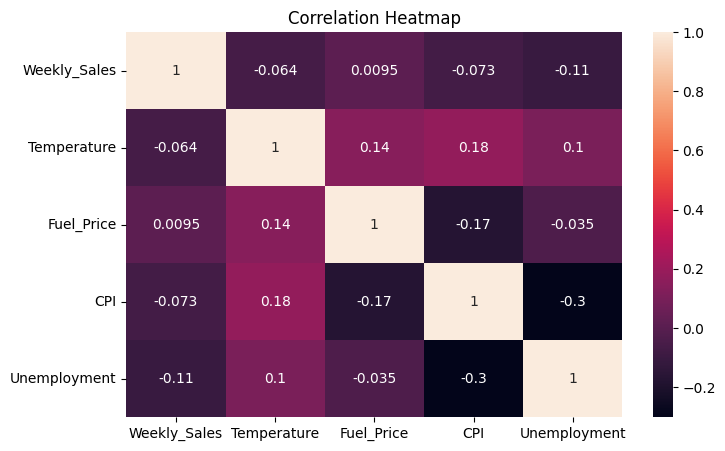

MAE: 61794.82
R2 Score: 0.9603
        Feature  Importance
0         Store    0.665969
4           CPI    0.155239
5  Unemployment    0.100718
8          Week    0.049988
2   Temperature    0.012873
3    Fuel_Price    0.010035
7         Month    0.002894
1  Holiday_Flag    0.001574
6          Year    0.000710


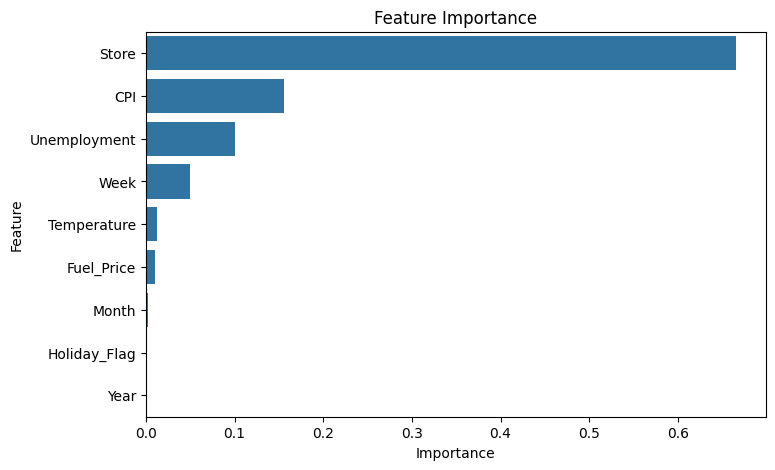

Predicted Weekly Sales: 1908376.76

Business Insights
- Holiday weeks generate higher sales.
- Certain stores consistently outperform others.
- Seasonal patterns significantly affect demand.
- Inventory should be increased before peak demand periods.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/content/Walmart.csv')

print(df.head())

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print(df.info())

print(df.describe())

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title('Weekly Sales Trend')
plt.show()

holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

holiday_sales.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Sales During Holidays')
plt.show()

top_stores = (
    df.groupby('Store')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_stores.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Performing Stores')
plt.show()

corr_cols = [
    'Weekly_Sales',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

plt.figure(figsize=(8,5))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True
)

plt.title('Correlation Heatmap')
plt.show()

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

X = df[
    [
        'Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Year',
        'Month',
        'Week'
    ]
]

y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    pred
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE:", round(mae,2))
print("R2 Score:", round(r2,4))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

future_sales = pd.DataFrame({
    'Store':[1],
    'Holiday_Flag':[1],
    'Temperature':[70],
    'Fuel_Price':[3.5],
    'CPI':[220],
    'Unemployment':[6],
    'Year':[2013],
    'Month':[12],
    'Week':[50]
})

prediction = model.predict(
    future_sales
)

print(
    "Predicted Weekly Sales:",
    round(prediction[0],2)
)

print("\nBusiness Insights")
print("- Holiday weeks generate higher sales.")
print("- Certain stores consistently outperform others.")
print("- Seasonal patterns significantly affect demand.")
print("- Inventory should be increased before peak demand periods.")